In [1]:
# %%
## Library
import os
import glob
import sys
import numpy as np
import shutil
import time
import speclite

start_time = time.time()

from astropy.coordinates import SkyCoord
from astropy.time import Time
from astropy import units as u
from astropy.io import fits
from astropy.table import Table
from astropy.table import vstack
from astropy.table import hstack
import warnings
warnings.filterwarnings("ignore")

### Plot presetting
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams["axes.titlesize"] = 14
mpl.rcParams["axes.labelsize"] = 20
plt.rcParams['savefig.dpi'] = 500
plt.rc('font', family='serif')

### Helper Functions
import sys
sys.path.append(os.path.join('..', 'src'))
from helper import makeSpecColors
from paths import *
from var import *
from sdtpy import *


In [2]:
# %%
logtxt = ""
# %%
# path_data = PHOT_7DT_DATA
# path_output_data = PHOT_7DT_DETECTED_DATA
# path_data = AUGMNETED_PHOT_7DT_DATA
# path_output_data = AUGMNETED_PHOT_7DT_DETECTED_DATA
# path_data = AUGMENTED_BALANCED_PHOT_7DT_DATA
# path_output_data = AUGMENTED_BALANCED_PHOT_7DT_DETECTED_DATA
path_data = PHOT_WOLLAEGER_7DT_DATA
path_output_data = PHOT_WOLLAEGER_7DT_DETECTED_DATA
# %%
# input_table_file = os.path.join(path_data, "synphot_normal_class.csv")
input_table_file = os.path.join(path_data, "synphot_anormaly_class.csv")
input_table = Table.read(input_table_file)
logtxt += f"Input Table: {input_table_file}\n"
logtxt += f"Number of Sources: {len(input_table)}\n"
# %%
filters = []
for key in input_table.keys():
	if 'magabs' in key:
		filters.append(key.split("_")[-1])
filters
logtxt += f"Number of Filters: {len(filters)}\n"


In [3]:
input_table['md'] = -99.
input_table['vd'] = -99.
input_table['mw'] = -99.
input_table['vw'] = -99.
input_table['ang'] = -99.
input_table['phase'] = -99.

for ss, specfile in enumerate(input_table['spec']):
    base_specfile = os.path.basename(specfile)
    parts = base_specfile.split("_")
    md = float(parts[2].replace("md", ""))
    vd = float(parts[3].replace("vd", ""))
    mw = float(parts[4].replace("mw", ""))
    vw = float(parts[5].replace("vw", ""))
    ang = float(parts[6].replace("ang", ""))
    phase = float(parts[7].replace("phase", "").replace(".fits", ""))
    #
    input_table['md'][ss] = md
    input_table['vd'][ss] = vd
    input_table['mw'][ss] = mw
    input_table['vw'][ss] = vw
    input_table['ang'][ss] = ang
    input_table['phase'][ss] = phase

In [4]:
# %%
#	Detection Check
indexes = []
for filte in filters:
	# Find the index of SNR > 5 → define as 'detection'
    snrkey = f"snr_{filte}"
    indx_detection = np.where(input_table[snrkey] > 5)
    indexes.append(indx_detection[0])  # np.where는 튜플을 반환하므로 첫 번째 요소만 사용합니다.

	# Convert the value of SNR < 3 as nan → define as 'non-detection' filter
    indx_nd = np.where(input_table[snrkey] < 3)
    input_table[snrkey][indx_nd] = np.nan

# 모든 필터에 대한 인덱스 배열을 하나로 결합합니다.
combined_indices = np.concatenate(indexes)

# unique 함수를 사용하여 중복을 제거합니다.
unique_indices = np.unique(combined_indices)

# boolean index array를 생성합니다.
# input_table의 행 수만큼 False로 초기화된 배열을 만듭니다.
bool_index_array = np.full(len(input_table), False)

# unique_indices에 있는 인덱스에 해당하는 위치를 True로 설정합니다.
bool_index_array[unique_indices] = True

    

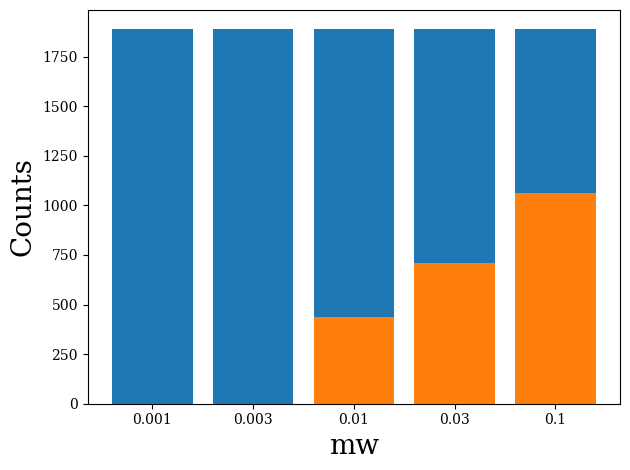

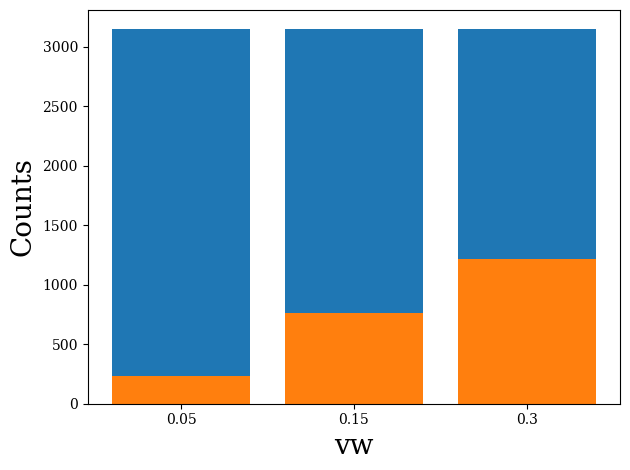

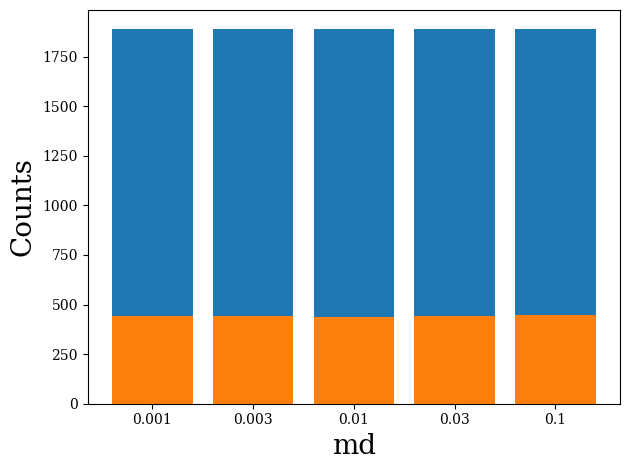

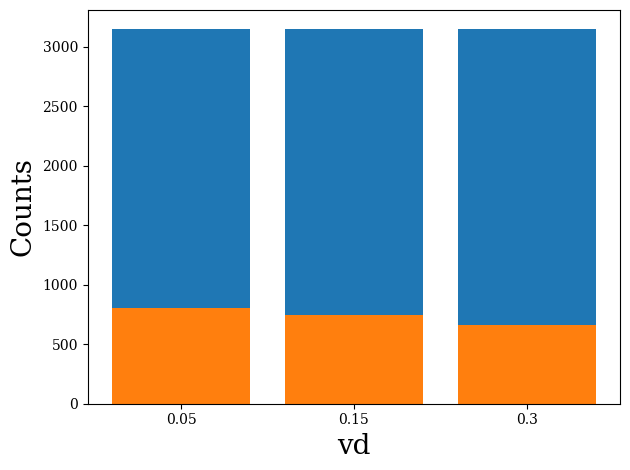

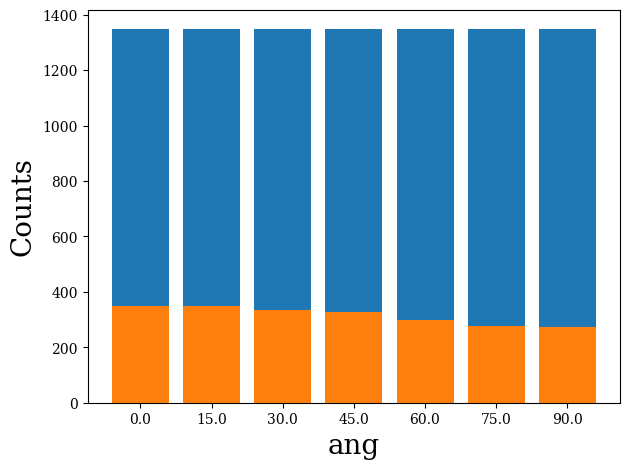

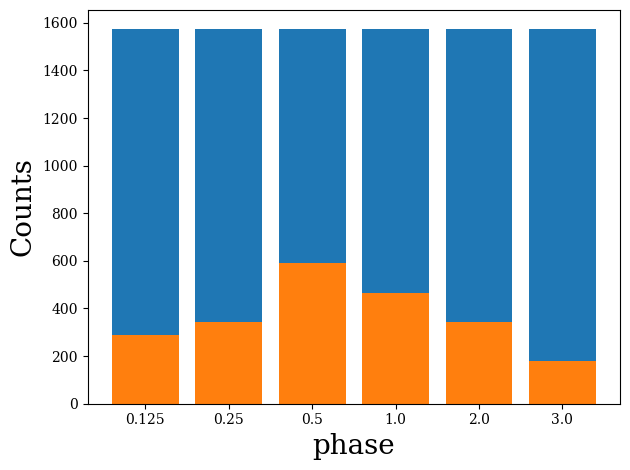

In [5]:
key = 'mw'

for key in ['mw', 'vw', 'md', 'vd', 'ang', 'phase']:
    values, counts = np.unique(input_table[key], return_counts=True)
    det_values, det_counts = np.unique(input_table[key][bool_index_array], return_counts=True)

    plt.bar([str(val) for val in values], counts)
    plt.bar([str(val) for val in det_values], det_counts)
    plt.xlabel(f"{key}")
    plt.ylabel("Counts")
    plt.tight_layout()
    plt.show()

In [6]:


# %%
#	Detection Table
output_table = input_table.copy()
output_table['detection'] = False
output_table['detection'][bool_index_array] = True
logtxt += f"Number of Detected Sources: {len(output_table)}\n"

output_table = output_table[bool_index_array]
output_table_name = os.path.join(path_output_data, "synphot_anormaly_class_detection.csv")
output_table.write(output_table_name, format='csv', overwrite=True)
print(f"{len(output_table)} sources detected among {len(input_table)} ({len(output_table)/len(input_table):.1%})")
logtxt += f"Number of Detected Sources: {len(output_table)}\n"
# %%
logtxt = "END\n"
print(logtxt)
with open(os.path.join(path_output_data, "log.txt"), "w") as f:
    f.write(logtxt)

2209 sources detected among 9450 (23.4%)
END

